## 对是否是高风险人群进行分类

### 前期准备模型、训练函数
##### 导入依赖的包

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import paddle
import paddle.nn as nn
import paddle.optimizer as optim
import paddle.nn.functional as F
from paddle.io import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler

# 设置随机种子确保结果可复现
paddle.seed(42)
np.random.seed(42)

#### 定义分类模型和训练函数
##### 定义分类模型

In [2]:
class HighRiskClassifier(nn.Layer):
    def __init__(self, input_size, hidden_layers=[128, 64], dropout_rate=0.3):
        super(HighRiskClassifier, self).__init__()
        
        layers = []
        prev_size = input_size
        
        # 构建隐藏层
        for hidden_size in hidden_layers:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.ReLU(),
                nn.BatchNorm1D(hidden_size),
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        self.hidden_layers = nn.Sequential(*layers)
        
        # 输出层 - 二分类输出
        self.output_layer = nn.Sequential(
            nn.Linear(prev_size, 1),
            nn.Sigmoid()
        )
        
        # 权重初始化 - 修复了PaddlePaddle特有的初始化方式
        self._initialize_weights()
    
    def _initialize_weights(self):
        for layer in self.sublayers():
            if isinstance(layer, nn.Linear):
                # Xavier均匀初始化权重
                nn.initializer.XavierUniform()(layer.weight)
                # 偏置初始化为0 - 修复点：使用nn.initializer.Constant
                if layer.bias is not None:
                    nn.initializer.Constant(value=0.0)(layer.bias)
            elif isinstance(layer, nn.BatchNorm1D):
                # BatchNorm的gamma初始化为1，beta初始化为0
                nn.initializer.Constant(value=1.0)(layer.weight)
                nn.initializer.Constant(value=0.0)(layer.bias)
    
    def forward(self, x):
        features = self.hidden_layers(x)
        probability = self.output_layer(features)
        return probability

##### 定义训练函数

In [3]:
def train_model(train_loader, val_loader, test_loader, model, lr=0.001, epochs=10,
                step_size=10, gamma=0.1, weight_decay=0, model_name="Unnamed_Model"):

    # 打印模型参数信息
    print(f"Total parameters: {sum(p.numpy().size for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numpy().size for p in model.parameters() if not p.stop_gradient):,}")
    print(f"Input features: {model.input_features if hasattr(model, 'input_features') else 'Not specified'}")
    
    # 设置损失函数和优化器
    criterion = nn.BCELoss()
    optimizer = optim.Adam(parameters=model.parameters(), learning_rate=lr, weight_decay=weight_decay)
    
    # 学习率调度器
    scheduler = paddle.optimizer.lr.StepDecay(lr, step_size=step_size, gamma=gamma)

    # 记录训练过程
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    learning_rates = []
    
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    patience_counter = 0
    early_stopping_patience = 15
    
    print(f"\nStarting training for {epochs} epochs...")
    print(f"Learning rate: {lr}, Weight decay: {weight_decay}")
    print("-" * 60)
    
    # 训练循环
    for epoch in range(epochs+1):
        # 训练阶段
        model.train()
        epoch_train_loss = 0
        train_correct = 0
        train_total = 0
        
        for batch_data in train_loader():
            batch_X, batch_y = batch_data
            
            # 前向传播
            pred_prob = model(batch_X)
            batch_y_float = batch_y.astype('float32').unsqueeze(1)
            
            # 计算损失
            loss = criterion(pred_prob, batch_y_float)
            
            # 反向传播
            loss.backward()
            optimizer.step()
            optimizer.clear_grad()
            
            epoch_train_loss += loss.item()
            
            # 计算训练准确率
            pred_labels = (pred_prob > 0.5).astype('float32')
            train_correct += (pred_labels == batch_y_float).astype('float32').sum().item()
            train_total += batch_y.shape[0]
        
        # 计算平均训练损失和准确率
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_accuracy = train_correct / train_total if train_total > 0 else 0
        
        # 验证阶段
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        
        with paddle.no_grad():
            for batch_data in val_loader():
                batch_X, batch_y = batch_data
                
                pred_prob = model(batch_X)
                batch_y_float = batch_y.astype('float32').unsqueeze(1)
                
                # 计算验证损失
                loss = criterion(pred_prob, batch_y_float)
                val_loss += loss.item()
                
                # 计算验证准确率
                pred_labels = (pred_prob > 0.5).astype('float32')
                val_correct += (pred_labels == batch_y_float).astype('float32').sum().item()
                val_total += batch_y.shape[0]
        
        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_accuracy = val_correct / val_total if val_total > 0 else 0
        
        # 记录训练过程
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        learning_rates.append(optimizer.get_lr())
        
        # 学习率调度
        scheduler.step(avg_val_loss)
        
        # 保存最佳模型
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
        
        # 打印训练进度
        if (epoch + 1) % 10 == 0 or epoch < 3:
            print(f'Epoch [{epoch+1}/{epochs}]')
            print(f'  Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
            print(f'  Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}')
            print()
        
        # 早停检查
        if patience_counter >= early_stopping_patience:
            print(f'\nEarly stopping triggered at epoch {epoch+1}')
            break
    
    # 加载最佳模型
    if best_model_state is not None:
        model.set_state_dict(best_model_state)
        print(f"\nLoaded best model from epoch {best_epoch+1}")
        print(f"Best validation loss: {best_val_loss:.6f}")
    
    # 在测试集上评估
    print(f"\n{'='*60}")
    print("Evaluating on Test Set")
    
    model.eval()
    test_pred_probs = []
    test_pred_labels = []
    test_true_labels = []
    
    with paddle.no_grad():
        for batch_data in test_loader():
            batch_X, batch_y = batch_data
            
            pred_prob = model(batch_X)
            batch_y_float = batch_y.astype('float32').unsqueeze(1)
            
            # 计算测试损失
            pred_labels = (pred_prob > 0.5).astype('float32')
            
            test_pred_probs.extend(pred_prob.numpy().flatten())
            test_pred_labels.extend(pred_labels.numpy().flatten())
            test_true_labels.extend(batch_y.numpy())
    
    # 转换为numpy数组
    test_pred_probs = np.array(test_pred_probs)
    test_pred_labels = np.array(test_pred_labels)
    test_true_labels = np.array(test_true_labels)
    
    # 计算评估指标
    test_accuracy = accuracy_score(test_true_labels, test_pred_labels)
    test_auc = roc_auc_score(test_true_labels, test_pred_probs)
    test_precision = precision_score(test_true_labels, test_pred_labels, zero_division=0)
    test_recall = recall_score(test_true_labels, test_pred_labels, zero_division=0)
    test_f1 = f1_score(test_true_labels, test_pred_labels, zero_division=0)
    
    # 计算混淆矩阵
    cm = confusion_matrix(test_true_labels, test_pred_labels)
    tn, fp, fn, tp = cm.ravel()
    
    # 打印测试结果
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {test_accuracy:.6f}")
    print(f"  AUC:       {test_auc:.6f}")
    print(f"  Precision: {test_precision:.6f}")
    print(f"  Recall:    {test_recall:.6f}")
    print(f"  F1 Score:  {test_f1:.6f}")
    
    print(f"\nConfusion Matrix Analysis:")
    print(f"  True Positives (TP):  {tp}")
    print(f"  True Negatives (TN):  {tn}")
    print(f"  False Positives (FP): {fp}")
    print(f"  False Negatives (FN): {fn}")
    
    # 计算其他统计量
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    prevalence = (tp + fn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    
    print(f"\nAdditional Statistics:")
    print(f"  Sensitivity (TPR): {sensitivity:.4f}")
    print(f"  Specificity (TNR): {specificity:.4f}")
    print(f"  Prevalence:       {prevalence:.4f}")
    
    # 绘制训练结果图表
    print(f"\n{'='*60}")
    print("Generating Visualization Charts")
    print(f"{'='*60}")
    
    # 创建综合图表
    fig = plt.figure(figsize=(20, 12))
    
    # 1. 训练和验证损失曲线
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(train_losses, label='Training Loss', color='blue', alpha=0.8, linewidth=2)
    ax1.plot(val_losses, label='Validation Loss', color='red', alpha=0.8, linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('BCE Loss', fontsize=12)
    ax1.set_title(f'Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 在最佳epoch处添加标记
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5, label=f'Best Epoch ({best_epoch+1})')
    ax1.legend()
    
    # 2. 训练和验证准确率曲线
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(train_accuracies, label='Training Accuracy', color='blue', alpha=0.8, linewidth=2)
    ax2.plot(val_accuracies, label='Validation Accuracy', color='red', alpha=0.8, linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title(f'Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])
    
    # 3. ROC曲线
    ax3 = plt.subplot(2, 3, 5)
    fpr, tpr, thresholds = roc_curve(test_true_labels, test_pred_probs)
    
    # 计算最佳阈值（基于Youden's J统计量）
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    
    ax3.plot(fpr, tpr, color='darkorange', linewidth=3, 
             label=f'ROC Curve (AUC = {test_auc:.3f})')
    ax3.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--', 
             alpha=0.5, label='Random Classifier')
    
    # 标记最佳阈值点
    ax3.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
             label=f'Optimal Threshold\n({optimal_threshold:.3f})')
    
    ax3.set_xlabel('False Positive Rate (FPR)', fontsize=12)
    ax3.set_ylabel('True Positive Rate (TPR)', fontsize=12)
    ax3.set_title(f'ROC Curve', fontsize=14, fontweight='bold')
    ax3.legend(loc='lower right')
    ax3.grid(True, alpha=0.3)
    ax3.set_aspect('equal', adjustable='box')
    
    # 4. 精确率-召回率曲线
    ax4 = plt.subplot(2, 3, 4)
    precision, recall, _ = precision_recall_curve(test_true_labels, test_pred_probs)
    
    # 计算平均精确率
    avg_precision = np.mean(precision)
    
    ax4.plot(recall, precision, color='green', linewidth=3)
    ax4.set_xlabel('Recall (Sensitivity)', fontsize=12)
    ax4.set_ylabel('Precision', fontsize=12)
    ax4.set_title(f'Precision-Recall Curve\n(AP = {avg_precision:.3f})', 
                  fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim([0, 1])
    ax4.set_ylim([0, 1.05])
    
    # 5. 混淆矩阵热图
    ax5 = plt.subplot(2, 3, 3)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                annot_kws={'size': 14}, 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'],
                cbar_kws={'label': 'Count'},
                ax=ax5)
    ax5.set_title(f'Confusion Matrix', fontsize=14, fontweight='bold')
    ax5.set_ylabel('True Label', fontsize=12)
    ax5.set_xlabel('Predicted Label', fontsize=12)
    plt.subplots_adjust(bottom=0.15, right=0.95)  # 关键
    
    # 6. 预测概率分布
    ax6 = plt.subplot(2, 3, 6)
    
    # 分别绘制正负样本的预测概率分布
    pos_probs = test_pred_probs[test_true_labels == 1]
    neg_probs = test_pred_probs[test_true_labels == 0]
    
    ax6.hist(neg_probs, bins=30, alpha=0.7, color='blue', 
             edgecolor='black', label='Negative Class', density=True)
    ax6.hist(pos_probs, bins=30, alpha=0.7, color='red', 
             edgecolor='black', label='Positive Class', density=True)
    
    # 添加决策阈值线
    ax6.axvline(x=0.5, color='green', linestyle='--', linewidth=2, 
                label=f'Decision Threshold (0.5)')
    
    # 添加最佳阈值线
    if optimal_threshold != 0.5:
        ax6.axvline(x=optimal_threshold, color='orange', linestyle='--', linewidth=2, 
                    alpha=0.7, label=f'Optimal Threshold\n({optimal_threshold:.3f})')
    
    ax6.set_xlabel('Predicted Probability', fontsize=12)
    ax6.set_ylabel('Density', fontsize=12)
    ax6.set_title(f'Probability Distribution', fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    ax6.set_xlim([0, 1])
    
    plt.suptitle(f'{model_name} Training Results Summary', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # 保存图表
    timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
    filename = f"training_results_{timestamp}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Training results saved to: {filename}")
    
    # 显示图表
    plt.show()
    
    # 创建性能指标表格
    print(f"\n{'='*60}")
    print("Performance Metrics Summary")
    print(f"{'='*60}")
    
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1 Score', 
                  'Sensitivity', 'Specificity', 'Best Val Loss', 'Best Epoch'],
        'Value': [f"{test_accuracy:.4f}", f"{test_auc:.4f}", f"{test_precision:.4f}", 
                 f"{test_recall:.4f}", f"{test_f1:.4f}", f"{sensitivity:.4f}", 
                 f"{specificity:.4f}", f"{best_val_loss:.6f}", f"{best_epoch+1}"]
    })
    
    print(metrics_df.to_string(index=False))
    print(f" the confusion matrix: {cm}")
    

### 建模、训练、评估、预测

#### 读取数据

In [4]:
# 读取数据
data = pd.read_csv("insurance_data_preprocessed.csv")


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95394 entries, 0 to 95393
Data columns (total 64 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              95394 non-null  int64  
 1   income                           95394 non-null  float64
 2   education                        95394 non-null  int64  
 3   household_size                   95394 non-null  int64  
 4   dependents                       95394 non-null  int64  
 5   bmi                              95394 non-null  float64
 6   smoker                           95394 non-null  int64  
 7   alcohol_freq                     95394 non-null  int64  
 8   visits_last_year                 95394 non-null  int64  
 9   hospitalizations_last_3yrs       95394 non-null  int64  
 10  days_hospitalized_last_3yrs      95394 non-null  int64  
 11  medication_count                 95394 non-null  int64  
 12  systolic_bp       

In [6]:
# 定义我们要使用的特征列表
selected_features = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'smoker',  # 基础健康指标

    'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',  # 慢性疾病
    'kidney_disease', 'liver_disease',  'cancer_history', 'arthritis', 'mental_health',
    
    'visits_last_year', 'medication_count', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',  # 医疗利用情况
    # 'risk_score',
    
    'proc_surgery_count', 'had_major_procedure', 'proc_imaging_count', 'proc_physio_count', # 手术/治疗历史
    'proc_consult_count', 'proc_lab_count',

    'sex_Male', 'sex_Other', 'education', 'region_East', 'region_North', 'region_South', 'region_West'] # 人口统计学特征
len(selected_features)

35

In [7]:
# 选择特征和目标变量
X = data[selected_features]
y = data['is_high_risk']

In [8]:
# 划分数据集
X_train, X_test0, y_train, y_test0 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test0, y_test0, test_size=0.5, random_state=42, stratify=y_test0)

In [9]:
def generate_data_loader(input, target, batch_size=64, shuffle=True, num_workers=0):
    input = paddle.to_tensor(input.values.astype('float32'))
    target = paddle.to_tensor(target.values.astype('int64'))
    dataset = TensorDataset([input, target])
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)

#### 采取所选数据的全部特征进行建模，并进行训练、测试、评估、分析等步骤。

#### 小模型

Total parameters: 817
Trainable parameters: 769
Input features: Not specified

Starting training for 100 epochs...
Learning rate: 0.001, Weight decay: 0
------------------------------------------------------------
Epoch [1/100]
  Train Loss: 0.335278, Val Loss: 0.237870
  Train Acc: 0.8440, Val Acc: 0.9032

Epoch [2/100]
  Train Loss: 0.181635, Val Loss: 0.156870
  Train Acc: 0.9214, Val Acc: 0.9367

Epoch [3/100]
  Train Loss: 0.177657, Val Loss: 0.156692
  Train Acc: 0.9235, Val Acc: 0.9356

Epoch [10/100]
  Train Loss: 0.172793, Val Loss: 0.141678
  Train Acc: 0.9254, Val Acc: 0.9411

Epoch [20/100]
  Train Loss: 0.172805, Val Loss: 0.165961
  Train Acc: 0.9233, Val Acc: 0.9218

Epoch [30/100]
  Train Loss: 0.170569, Val Loss: 0.140405
  Train Acc: 0.9253, Val Acc: 0.9380

Epoch [40/100]
  Train Loss: 0.168177, Val Loss: 0.159496
  Train Acc: 0.9258, Val Acc: 0.9276


Early stopping triggered at epoch 47

Loaded best model from epoch 32
Best validation loss: 0.137356

Evaluating on 

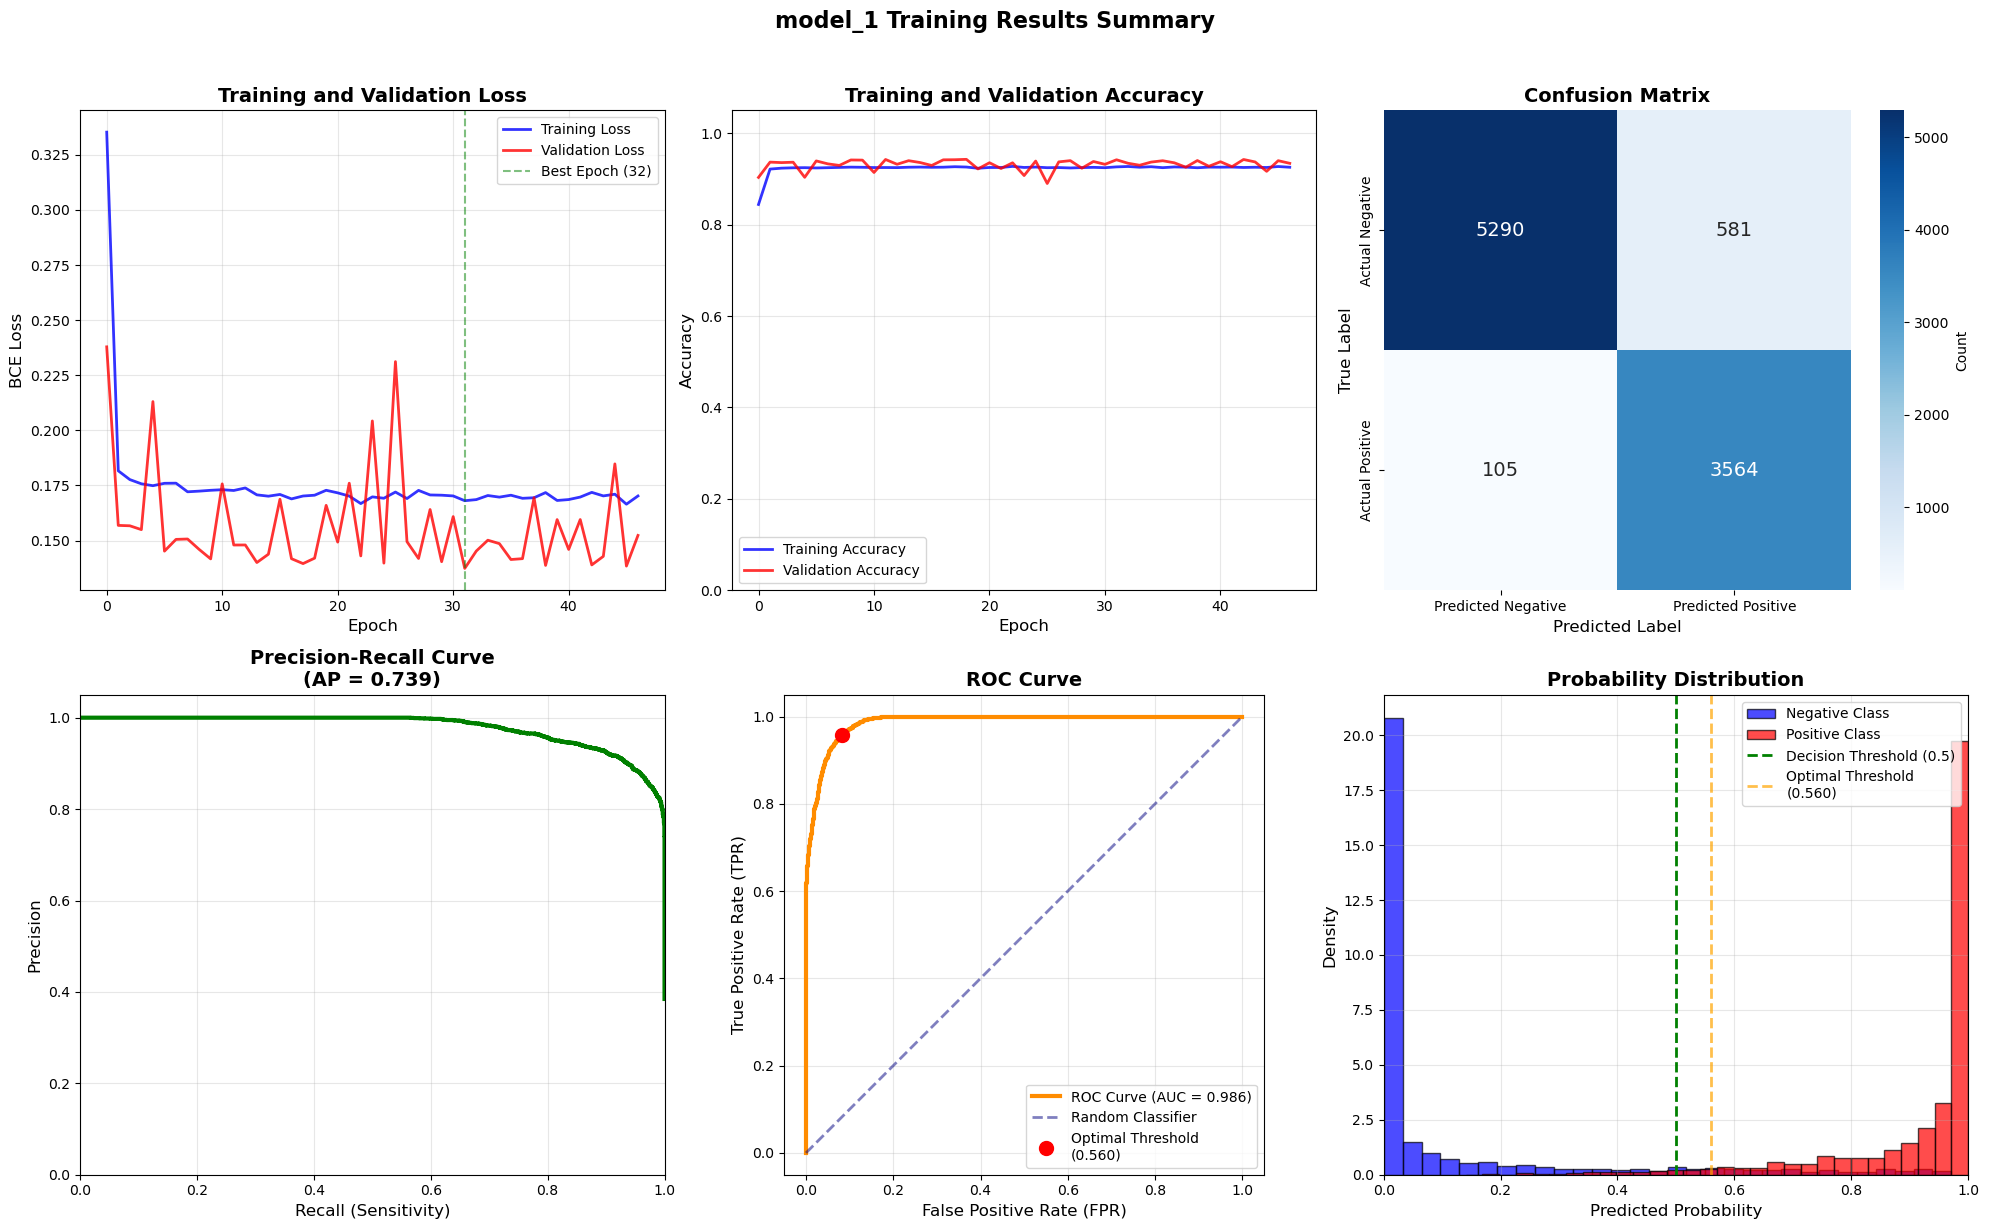


Performance Metrics Summary
       Metric    Value
     Accuracy   0.9281
          AUC   0.9864
    Precision   0.8598
       Recall   0.9714
     F1 Score   0.9122
  Sensitivity   0.9714
  Specificity   0.9010
Best Val Loss 0.137356
   Best Epoch       32
 the confusion matrix: [[5290  581]
 [ 105 3564]]
Time Cost: 82.75083923339844 s


In [12]:
import time
time_start = time.time()
batch_size = 64

lr = 0.001
num_epochs = 100
input_size = X_train.shape[1]
hidden_layers = [16, 8]
dropout_rate = 0.1
step_size=10
gamma=0.1

model = HighRiskClassifier(input_size=input_size, hidden_layers=hidden_layers, dropout_rate=dropout_rate)


train_loader =generate_data_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader =generate_data_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader =generate_data_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

train_model(train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, model=model,
            lr=lr, epochs=num_epochs, step_size=step_size, gamma=gamma, model_name='model_1')

time_end = time.time()
print("Time Cost:", time_end - time_start, "s")

##### 较大的模型

Total parameters: 2,049
Trainable parameters: 1,937
Input features: Not specified

Starting training for 100 epochs...
Learning rate: 0.001, Weight decay: 0
------------------------------------------------------------
Epoch [1/100]
  Train Loss: 0.283028, Val Loss: 0.148235
  Train Acc: 0.8744, Val Acc: 0.9389

Epoch [2/100]
  Train Loss: 0.184031, Val Loss: 0.144552
  Train Acc: 0.9208, Val Acc: 0.9396

Epoch [3/100]
  Train Loss: 0.160609, Val Loss: 0.132979
  Train Acc: 0.9295, Val Acc: 0.9408

Epoch [10/100]
  Train Loss: 0.126777, Val Loss: 0.086419
  Train Acc: 0.9464, Val Acc: 0.9657

Epoch [20/100]
  Train Loss: 0.120262, Val Loss: 0.076861
  Train Acc: 0.9484, Val Acc: 0.9686


Early stopping triggered at epoch 28

Loaded best model from epoch 13
Best validation loss: 0.073833

Evaluating on Test Set

Test Set Performance:
  Accuracy:  0.960063
  AUC:       0.996522
  Precision: 0.921755
  Recall:    0.979286
  F1 Score:  0.949650

Confusion Matrix Analysis:
  True Positives (

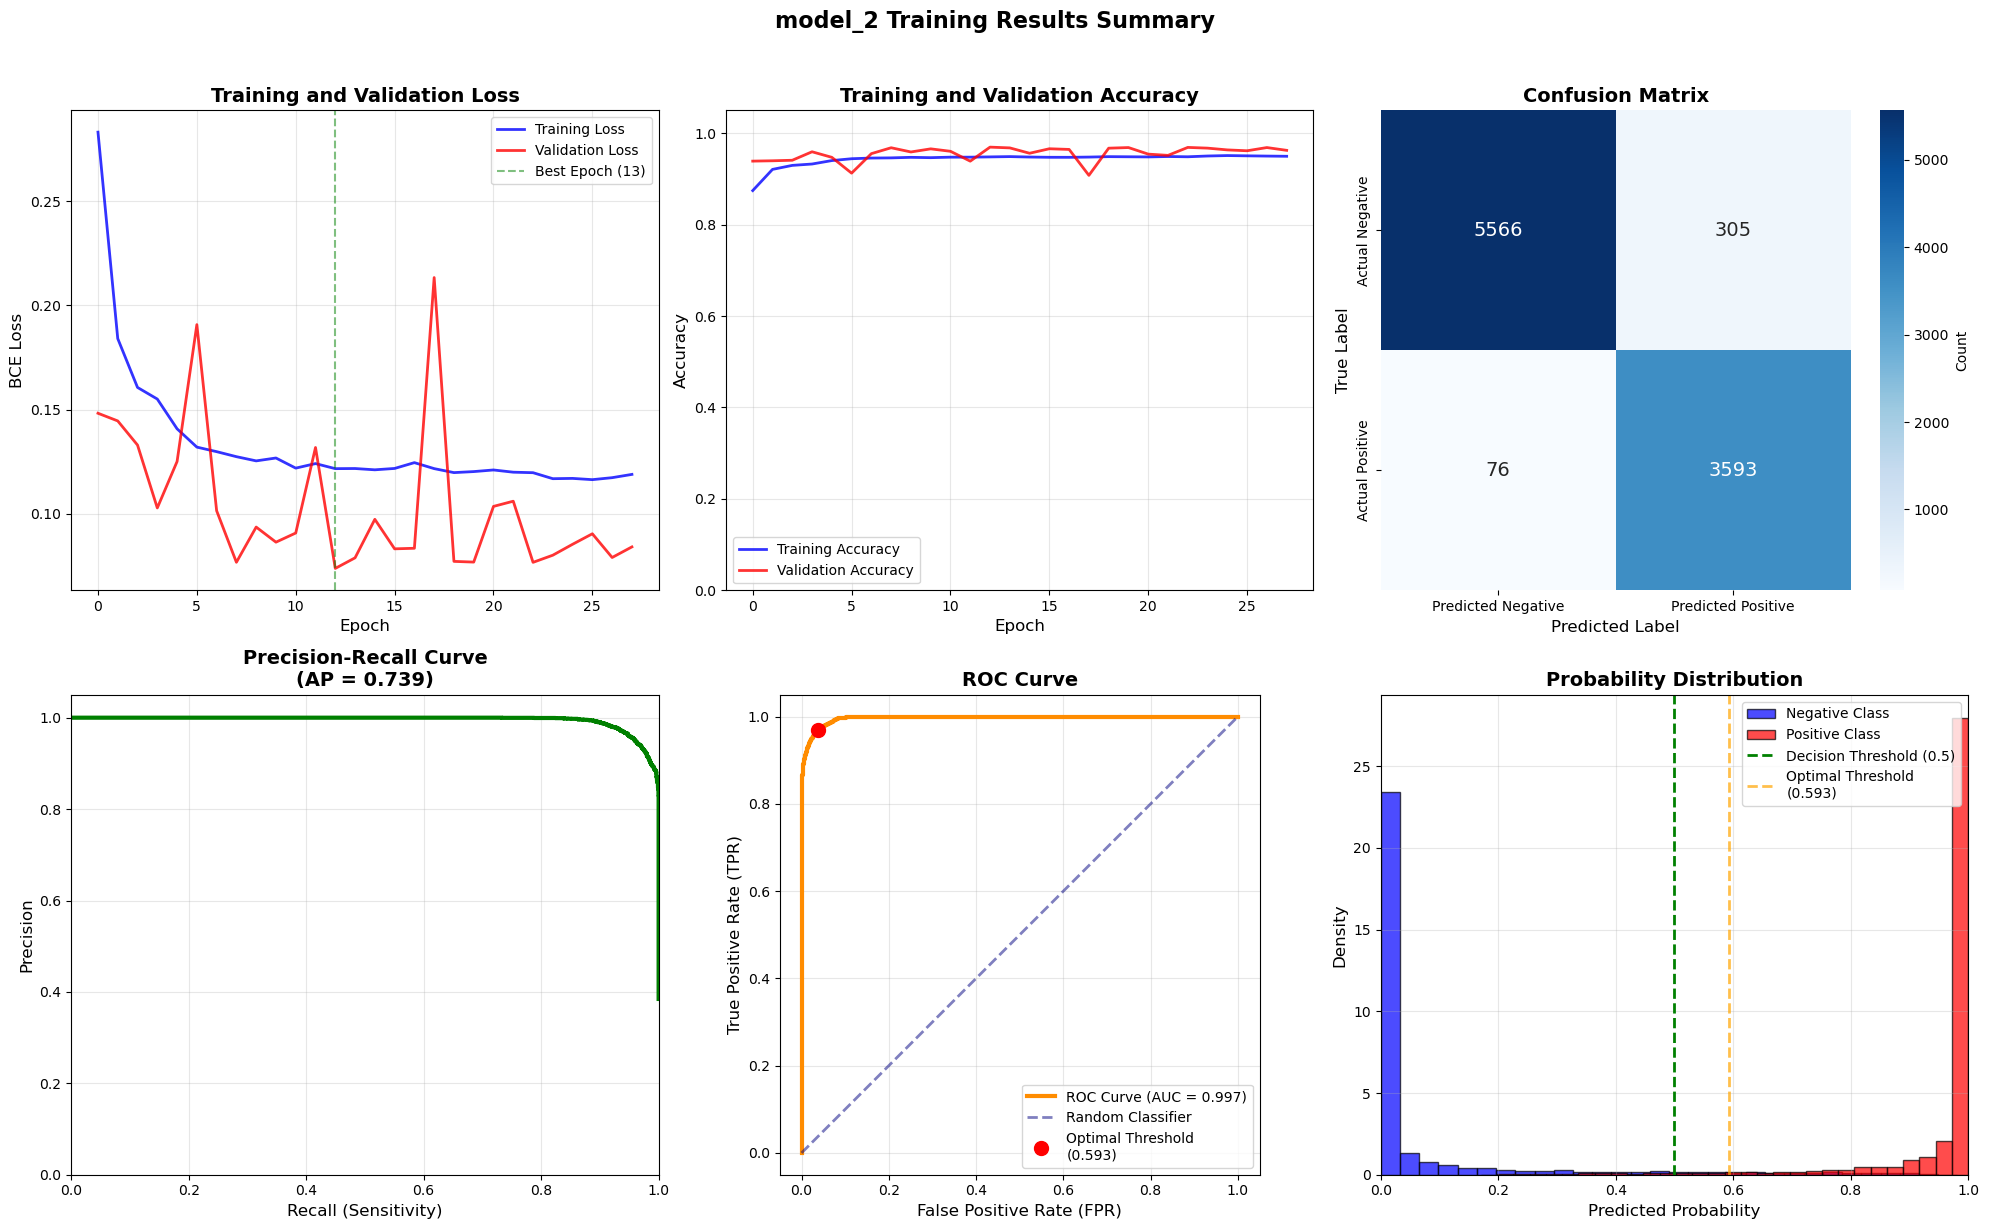


Performance Metrics Summary
       Metric    Value
     Accuracy   0.9601
          AUC   0.9965
    Precision   0.9218
       Recall   0.9793
     F1 Score   0.9496
  Sensitivity   0.9793
  Specificity   0.9480
Best Val Loss 0.073833
   Best Epoch       13
 the confusion matrix: [[5566  305]
 [  76 3593]]
Time Cost: 55.1337947845459 s


In [ ]:
import time
time_start = time.time()
batch_size = 64

lr = 0.001
num_epochs = 100
input_size = X_train.shape[1]
hidden_layers = [32, 16, 8]
dropout_rate = 0.1
step_size=10
gamma=0.1

model = HighRiskClassifier(input_size=input_size, hidden_layers=hidden_layers, dropout_rate=dropout_rate)


train_loader =generate_data_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader =generate_data_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader =generate_data_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

train_model(train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, model=model,
            lr=lr, epochs=num_epochs, step_size=step_size, gamma=gamma, model_name='model_2')

time_end = time.time()
print("Time Cost:", time_end - time_start, "s")

Total parameters: 3,233
Trainable parameters: 3,057
Input features: Not specified

Starting training for 100 epochs...
Learning rate: 0.001, Weight decay: 0
------------------------------------------------------------
Epoch [1/100]
  Train Loss: 0.318302, Val Loss: 0.170925
  Train Acc: 0.8579, Val Acc: 0.9226

Epoch [2/100]
  Train Loss: 0.191324, Val Loss: 0.143900
  Train Acc: 0.9171, Val Acc: 0.9379

Epoch [3/100]
  Train Loss: 0.160310, Val Loss: 0.142002
  Train Acc: 0.9295, Val Acc: 0.9383

Epoch [10/100]
  Train Loss: 0.118566, Val Loss: 0.069087
  Train Acc: 0.9501, Val Acc: 0.9725

Epoch [20/100]
  Train Loss: 0.110537, Val Loss: 0.055116
  Train Acc: 0.9539, Val Acc: 0.9860

Epoch [30/100]
  Train Loss: 0.106575, Val Loss: 0.053134
  Train Acc: 0.9549, Val Acc: 0.9868

Epoch [40/100]
  Train Loss: 0.106075, Val Loss: 0.110643
  Train Acc: 0.9555, Val Acc: 0.9429

Epoch [50/100]
  Train Loss: 0.103207, Val Loss: 0.060026
  Train Acc: 0.9557, Val Acc: 0.9797


Early stopping t

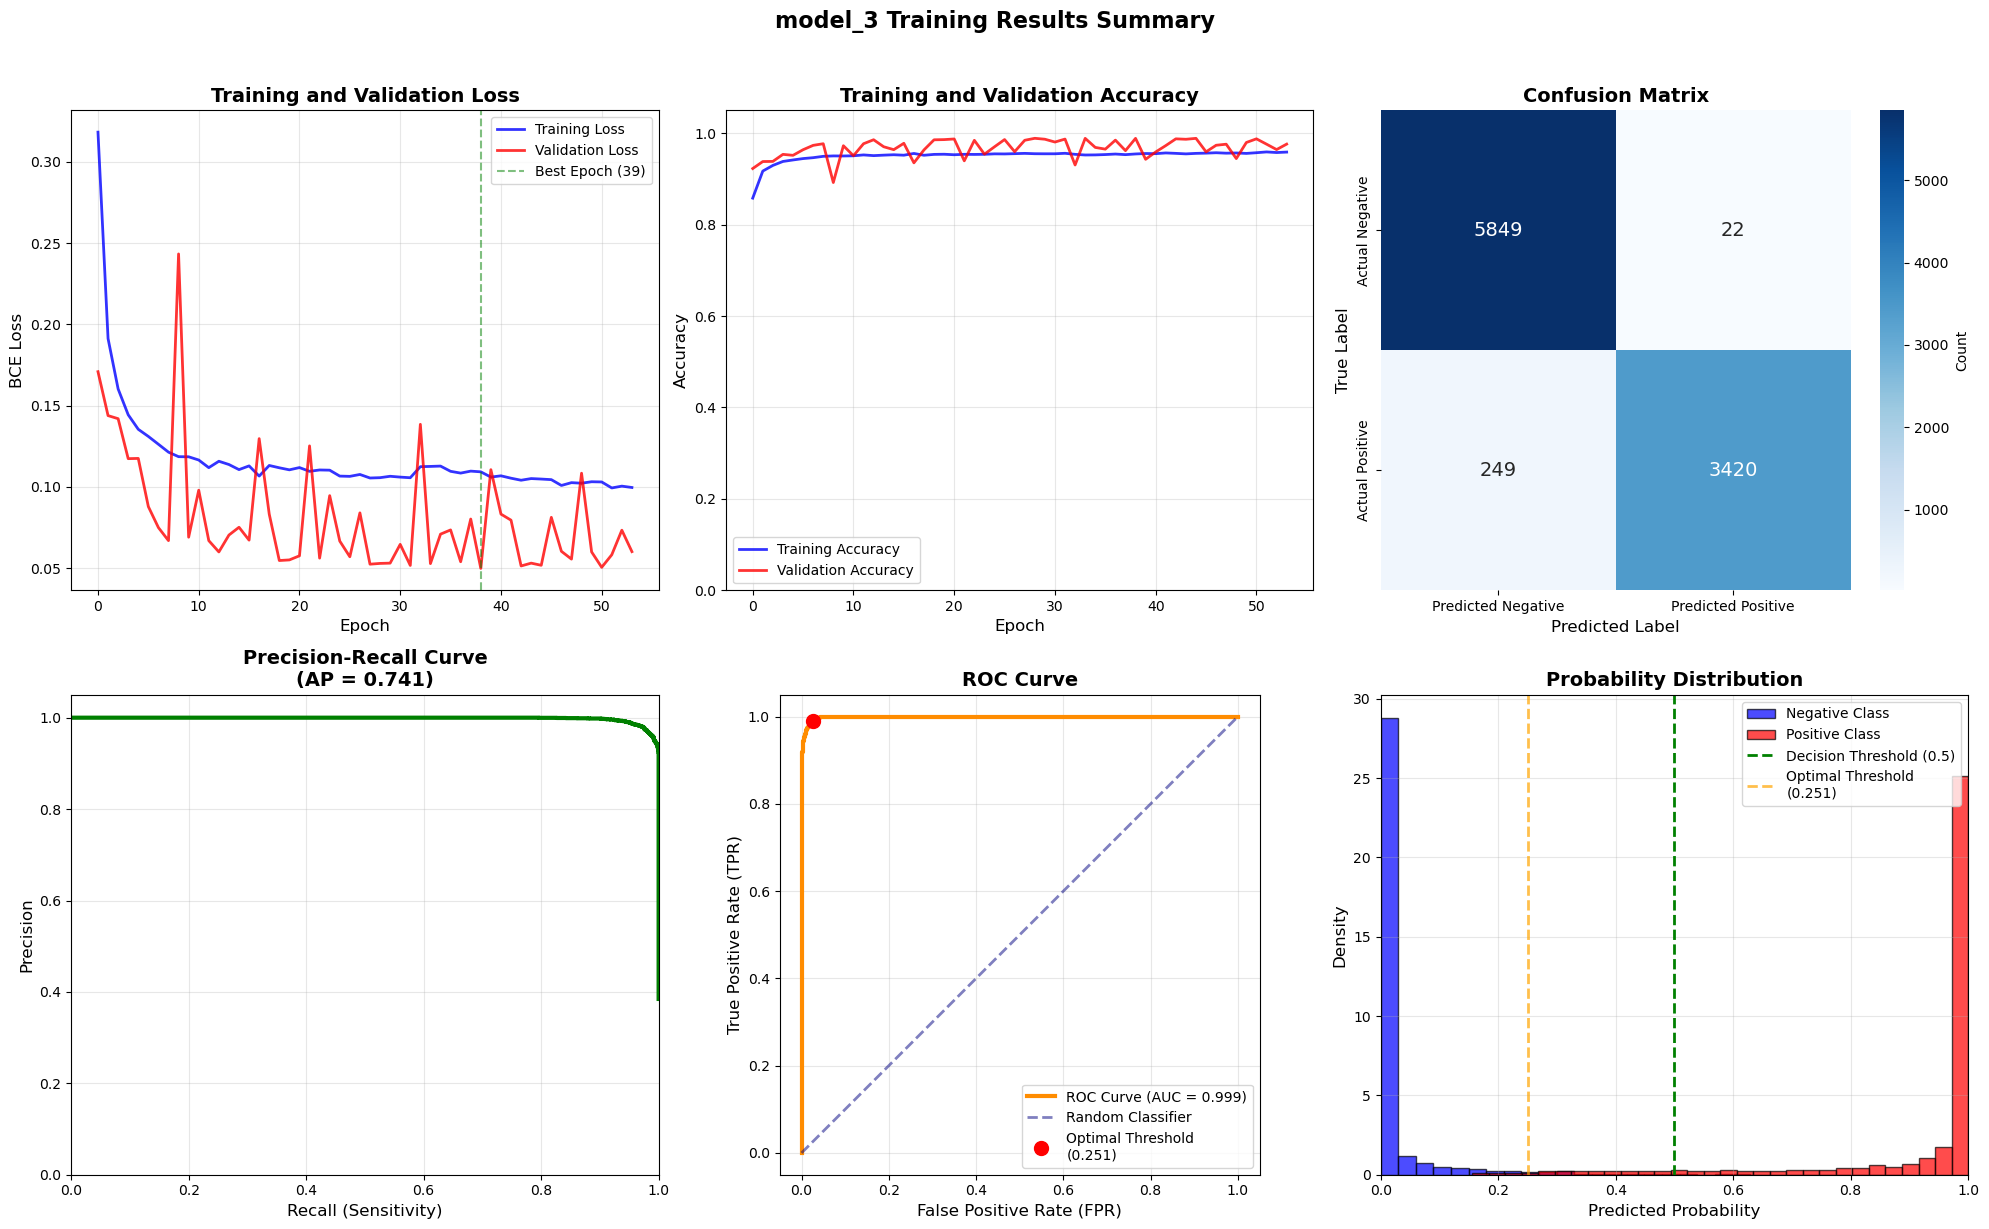


Performance Metrics Summary
       Metric    Value
     Accuracy   0.9716
          AUC   0.9989
    Precision   0.9936
       Recall   0.9321
     F1 Score   0.9619
  Sensitivity   0.9321
  Specificity   0.9963
Best Val Loss 0.049887
   Best Epoch       39
 the confusion matrix: [[5849   22]
 [ 249 3420]]
Time Cost: 99.25644373893738 s


In [14]:
import time
time_start = time.time()
batch_size = 64

lr = 0.001
num_epochs = 100
input_size = X_train.shape[1]
hidden_layers = [32, 32, 16, 8]
dropout_rate = 0.1
step_size=10
gamma=0.1

model = HighRiskClassifier(input_size=input_size, hidden_layers=hidden_layers, dropout_rate=dropout_rate)


train_loader =generate_data_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader =generate_data_loader(X_val, y_val, batch_size=batch_size, shuffle=False)
test_loader =generate_data_loader(X_test, y_test, batch_size=batch_size, shuffle=False)

train_model(train_loader=train_loader, val_loader=val_loader, test_loader=test_loader, model=model,
            lr=lr, epochs=num_epochs, step_size=step_size, gamma=gamma, model_name='model_3')

time_end = time.time()
print("Time Cost:", time_end - time_start, "s")